# PKCERT Task 13 – Advanced Model Evaluation & Handling Imbalanced Data

**Objective:** Develop practical skills in evaluating classification models using ROC-AUC
curves, learning curves, and techniques for handling imbalanced datasets such as SMOTE and
class weighting.

**Dataset:** the **Mammography** dataset (Woods et al., 1993) — 11,183 candidate regions from
digitized mammograms, labeled as either background/benign (majority) or a calcification
(minority, the clinically significant finding). Only **2.32%** of rows are the minority class,
making it a genuinely, realistically imbalanced dataset (not a mild ~60/40 split) — this exact
dataset is one of the original benchmarks used in Chawla et al.'s 2002 SMOTE paper, which makes
it a fitting choice for a task centered on SMOTE and class weighting.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import imblearn

from imblearn.datasets import fetch_datasets
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix,
)

import os
os.makedirs("visualizations", exist_ok=True)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

numpy: 1.26.4
pandas: 2.1.4
matplotlib: 3.8.0
seaborn: 0.12.2
scikit-learn: 1.2.2
imbalanced-learn: 0.11.0


## Part A – Dataset Selection & Preparation (15 Marks)

### A.1 & A.2 Dataset, Features and Target

`imblearn.datasets.fetch_datasets(filter_data=('mammography',))` — 11,183 rows, 6 numeric
features (image-processing descriptors of each candidate region extracted from the digitized
mammograms, already standardized in the source dataset), and a binary target:
`1 = calcification` (the minority, medically significant class — a potential cancer marker),
`0 = background/benign` (the overwhelming majority). This dataset is fetched once from
`imbalanced-learn`'s bundled benchmark collection and cached locally afterwards.

In [2]:
bunch = fetch_datasets(filter_data=('mammography',))["mammography"]
X_raw, y_raw = bunch.data, bunch.target
y = (y_raw == 1).astype(int)  # relabel {-1, 1} -> {0, 1}

df = pd.DataFrame(X_raw, columns=[f"feature_{i+1}" for i in range(X_raw.shape[1])])
df["target"] = y

print("Shape:", df.shape)
print("\nMissing values total:", df.isna().sum().sum())
print("\nClass counts:")
print(df["target"].value_counts().rename(index={0: "background (majority)", 1: "calcification (minority)"}))
print(f"\nMinority class share: {df['target'].mean()*100:.2f}%")

df.head()

Shape: (11183, 7)

Missing values total: 0

Class counts:
target
background (majority)       10923
calcification (minority)      260
Name: count, dtype: int64

Minority class share: 2.32%


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,target
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,0
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,0
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,0
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,0
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,0


### A.3 Preprocessing & Train/Test Split

- **Missing values** — none, no imputation needed.
- **Scaling** — Logistic Regression is scale-sensitive, so `StandardScaler` is fit on the
  training split only and applied to both splits.
- **Stratified split** — with only 260 minority-class rows total, an ordinary random split
  risks skewing the already-tiny minority proportion between train and test purely by chance.
  `stratify=y` keeps the ~2.32% minority ratio consistent in both splits, and the split is done
  **before** any resampling — SMOTE and class weighting (Part C) are applied only to the
  training data, never the test set, so test-set evaluation always reflects the real-world
  imbalanced distribution.

In [3]:
X = df.drop(columns="target")
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class counts:", np.bincount(y_train), f"({y_train.mean()*100:.2f}% minority)")
print("Test class counts: ", np.bincount(y_test), f"({y_test.mean()*100:.2f}% minority)")

Train shape: (8387, 6), Test shape: (2796, 6)
Train class counts: [8192  195] (2.33% minority)
Test class counts:  [2731   65] (2.32% minority)


## Part B – Advanced Model Evaluation (35 Marks)

### B.1 Baseline Classification Model

A plain Logistic Regression trained directly on the (scaled) imbalanced training data, with no
resampling or class weighting — this is the baseline every technique in Part C is measured
against.

In [4]:
baseline = LogisticRegression(max_iter=5000, random_state=42)
baseline.fit(X_train_scaled, y_train)
y_pred_base = baseline.predict(X_test_scaled)
y_proba_base = baseline.predict_proba(X_test_scaled)[:, 1]

print(f"Baseline accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Baseline recall (minority/calcification): {recall_score(y_test, y_pred_base):.4f}")

Baseline accuracy: 0.9825
Baseline recall (minority/calcification): 0.3692


### B.2 ROC Curve & ROC-AUC

The ROC curve plots true positive rate against false positive rate across every possible
decision threshold, and ROC-AUC summarizes it as the probability the model ranks a random
positive example above a random negative one — unlike accuracy, both are unaffected by the
class imbalance itself (they don't change if the minority class were 2% or 20% of the data),
which is exactly why they matter here.

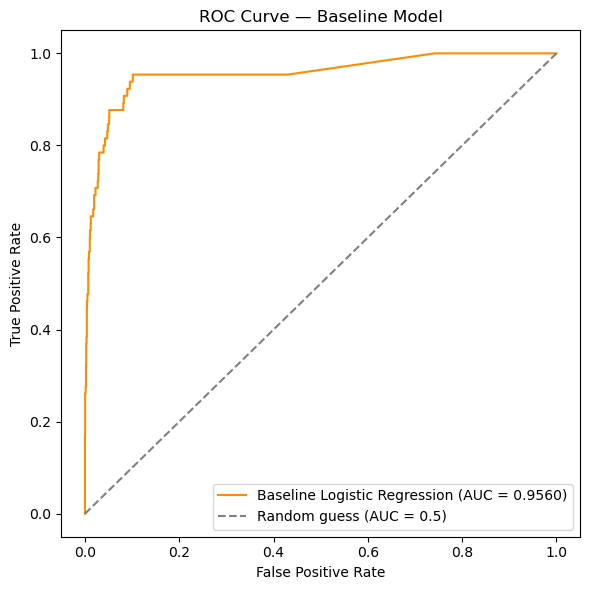

ROC-AUC: 0.9560


In [5]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_base)
auc_base = roc_auc_score(y_test, y_proba_base)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Baseline Logistic Regression (AUC = {auc_base:.4f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("visualizations/1_roc_curve_baseline.png", dpi=150)
plt.show()

print(f"ROC-AUC: {auc_base:.4f}")

**Interpretation:** an AUC of **0.956** means the baseline model is very good at *ranking*
calcifications above background regions by predicted probability — yet, as B.1 showed, its
default 0.5-threshold **recall is only 0.37** (it misses most true calcifications). This is the
central lesson of Part B: a high ROC-AUC shows the model has learned a strong underlying
separation between the classes, but the default classification threshold, combined with the
2.32% imbalance, still produces a classifier that's practically unfit for a screening use case
where missing a real calcification is the costly error. That gap is exactly what Part C's
resampling/weighting techniques target.

### B.3 Learning Curve

Training and 5-fold stratified cross-validation ROC-AUC are tracked as the training set size
grows from 10% to 100%, to check whether the model is underfitting (both scores low, close
together), overfitting (large, persistent gap between them), or generalizing well (scores
converge to a stable value).

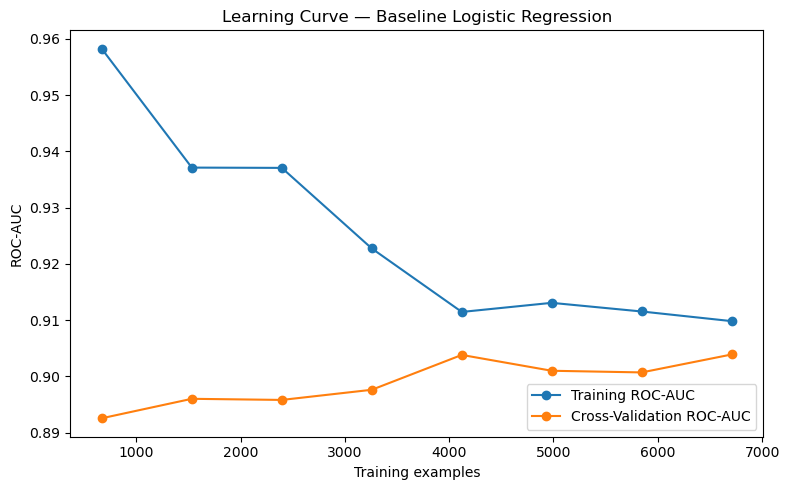

n=  670  train AUC=0.9582  val AUC=0.8926  gap=0.0657
n= 1533  train AUC=0.9371  val AUC=0.8960  gap=0.0411
n= 2396  train AUC=0.9371  val AUC=0.8958  gap=0.0412
n= 3258  train AUC=0.9228  val AUC=0.8976  gap=0.0251
n= 4121  train AUC=0.9115  val AUC=0.9038  gap=0.0076
n= 4983  train AUC=0.9131  val AUC=0.9010  gap=0.0121
n= 5846  train AUC=0.9115  val AUC=0.9007  gap=0.0108
n= 6709  train AUC=0.9098  val AUC=0.9039  gap=0.0059


In [6]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=5000, random_state=42),
    X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    random_state=42,
)

train_mean, val_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training ROC-AUC")
plt.plot(train_sizes, val_mean, marker="o", label="Cross-Validation ROC-AUC")
plt.xlabel("Training examples")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve — Baseline Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("visualizations/2_learning_curve.png", dpi=150)
plt.show()

for ts, tm, vm in zip(train_sizes, train_mean, val_mean):
    print(f"n={int(ts):5d}  train AUC={tm:.4f}  val AUC={vm:.4f}  gap={tm-vm:.4f}")

**Interpretation:** training AUC starts high (0.958 at the smallest size) and *decreases* as
more data is added, while validation AUC starts lower (0.893) and *increases* — they converge
to a small, stable gap (~0.006–0.02) by the largest training sizes. This is the classic
signature of a model that is **not overfitting** (the gap never widens) and **not badly
underfitting** either (both curves plateau at a respectable ~0.91 rather than a low score) —
Logistic Regression's linear decision boundary is evidently a reasonable fit for this data, and
the flattening curve suggests more training data alone would yield only marginal further gains;
a more expressive model would be the next lever to pull for higher ceiling performance, not more
rows.

## Part C – Handling Imbalanced Data (35 Marks)

### C.1 Analyzing the Class Imbalance

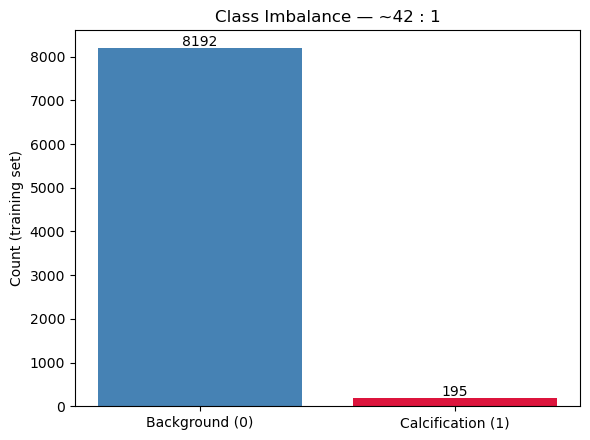

Training set imbalance ratio: 42.0 : 1 (background : calcification)
A classifier that always predicts 'background' would score 97.68% accuracy on the test set without learning anything.


In [7]:
counts = y_train.value_counts().sort_index()
ratio = counts[0] / counts[1]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bar(["Background (0)", "Calcification (1)"], counts.values, color=["steelblue", "crimson"])
ax.set_ylabel("Count (training set)")
ax.set_title(f"Class Imbalance — ~{ratio:.0f} : 1")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center")
plt.tight_layout()
plt.savefig("visualizations/3_class_imbalance.png", dpi=150)
plt.show()

print(f"Training set imbalance ratio: {ratio:.1f} : 1 (background : calcification)")
print(f"A classifier that always predicts 'background' would score "
      f"{(1 - y_test.mean())*100:.2f}% accuracy on the test set without learning anything.")

With a ~42:1 imbalance ratio, **accuracy is a misleading metric** here — always predicting
the majority class scores 97.68% accuracy trivially, and the baseline model's own 98.25%
accuracy (Part B.1) similarly hides that it misses most of the minority class. This motivates
Part C: rebalance the *training* data so the model is forced to pay attention to the minority
class, without touching the test set's real-world distribution.

### C.2 SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates new synthetic minority-class
examples by interpolating between each real minority point and its nearest minority neighbors,
rather than simply duplicating existing rows — applied to the **training set only**, then a
fresh Logistic Regression is trained on the rebalanced data and evaluated on the untouched,
still-imbalanced test set.

In [8]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE: ", np.bincount(y_train_smote))

smote_model = LogisticRegression(max_iter=5000, random_state=42)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test_scaled)
y_proba_smote = smote_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nSMOTE model recall (minority): {recall_score(y_test, y_pred_smote):.4f}")

Before SMOTE: [8192  195]
After SMOTE:  [8192 8192]

SMOTE model recall (minority): 0.9077


### C.3 Class Weighting & Full Comparison

`class_weight="balanced"` reweights the loss function inversely proportional to class
frequency, penalizing minority-class mistakes more heavily — a cheaper alternative to SMOTE
that changes the training objective rather than the training data itself.

In [9]:
cw_model = LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced")
cw_model.fit(X_train_scaled, y_train)
y_pred_cw = cw_model.predict(X_test_scaled)
y_proba_cw = cw_model.predict_proba(X_test_scaled)[:, 1]

print(f"Class-weighted model recall (minority): {recall_score(y_test, y_pred_cw):.4f}")

Class-weighted model recall (minority): 0.8615


In [10]:
def metrics_row(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    metrics_row("Baseline (imbalanced)", y_test, y_pred_base, y_proba_base),
    metrics_row("SMOTE", y_test, y_pred_smote, y_proba_smote),
    metrics_row("Class-weighted", y_test, y_pred_cw, y_proba_cw),
]).set_index("Model").round(4)

results

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Baseline (imbalanced),0.9825,0.7500,0.3692,0.4948,0.9560
SMOTE,0.9056,0.1861,0.9077,0.3089,0.9471
Class-weighted,0.9045,0.1783,0.8615,0.2955,0.9423


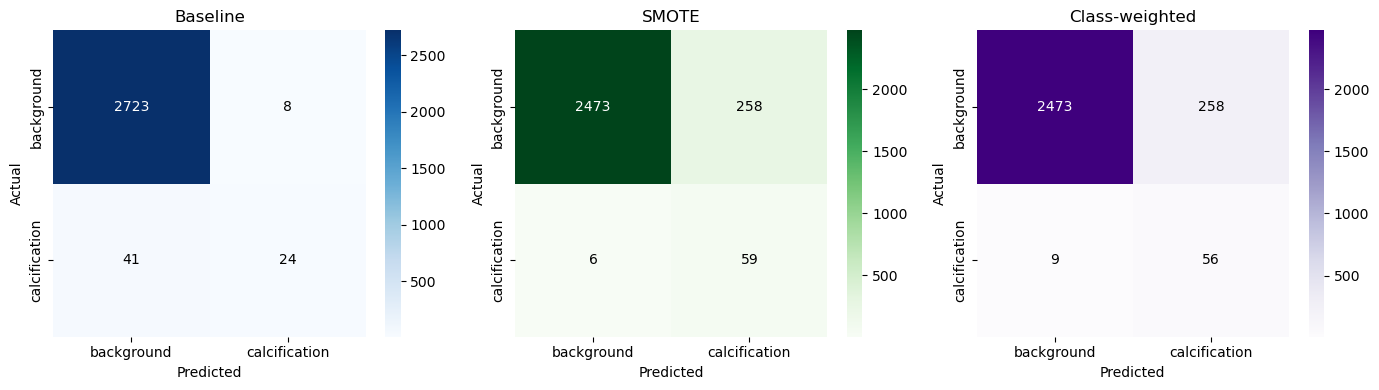

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, y_pred, title, cmap in [
    (axes[0], y_pred_base, "Baseline", "Blues"),
    (axes[1], y_pred_smote, "SMOTE", "Greens"),
    (axes[2], y_pred_cw, "Class-weighted", "Purples"),
]:
    cm = confusion_matrix(y_test, y_pred)
    # seaborn 0.12.2 + matplotlib 3.8 silently drops annot=True text on some rows,
    # so the cell numbers are added manually below instead.
    sns.heatmap(cm, annot=False, cmap=cmap,
                xticklabels=["background", "calcification"],
                yticklabels=["background", "calcification"], ax=ax)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > cm.max() * 0.5 else "black"
            ax.text(j + 0.5, i + 0.5, str(cm[i, j]), ha="center", va="center", color=color)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("visualizations/4_confusion_matrices.png", dpi=150)
plt.show()

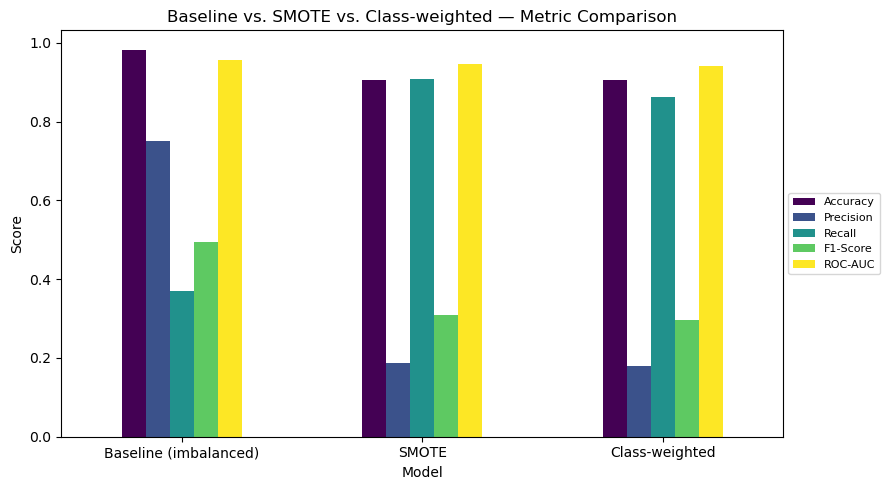

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
results.plot(kind="bar", ax=ax, colormap="viridis")
ax.set_title("Baseline vs. SMOTE vs. Class-weighted — Metric Comparison")
ax.set_ylabel("Score")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("visualizations/5_metric_comparison.png", dpi=150)
plt.show()

**Observations:** both SMOTE and class weighting more than double recall versus the
baseline (0.908 and 0.862 vs. 0.369) — they catch far more true calcifications — but at a steep
precision cost (0.186 and 0.178 vs. 0.750), because both push the model to flag many more
borderline background regions as positive too. Accuracy and F1-score actually *drop* for both
rebalancing techniques (F1 falls from 0.495 to ~0.30), which looks like a regression on paper
but is the expected, deliberate trade-off of prioritizing recall on a 42:1-imbalanced problem —
F1 weights precision and recall equally, but that isn't necessarily the right trade-off for this
domain (see D.1). Notably, **ROC-AUC barely moves** across all three (0.956 / 0.947 / 0.942):
the underlying ranking ability of the model is largely unchanged by resampling/weighting — what
changes is *where the default 0.5 threshold falls* relative to that ranking, which confirms
Part B.2's point that AUC and thresholded metrics answer different questions.

## Part D – Comparative Analysis & Recommendation (15 Marks)

### D.1 Recommendation

In a mammography-screening context, a **false negative** (a real calcification predicted as
background) is far costlier than a **false positive** (a benign region flagged for a follow-up
look) — which makes **recall the metric to prioritize**, not accuracy or F1. Judged on that
basis:

- **Baseline** — rejected. Despite the best accuracy (0.983), F1 (0.495), and precision (0.750),
  it misses **41 of 65** true calcifications in the test set (recall 0.369) — over 60% of real
  cases slip through, which defeats the purpose of a screening model.
- **SMOTE** — recommended. Highest recall (**0.908** — misses only 6 of 65 cases), and edges out
  class weighting on every other metric measured too (F1 0.309 vs. 0.296, ROC-AUC 0.947 vs.
  0.942), at the cost of more false positives (258 vs. baseline's 8) that would need a
  (cheaper, non-invasive) follow-up read.
- **Class-weighted** — a close second and a reasonable lighter-weight alternative (no synthetic
  data generation, trains directly on the original data with a reweighted loss) when the SMOTE
  step itself is undesirable (e.g. very high-dimensional data where interpolation is less
  meaningful), but it's dominated by SMOTE on every metric measured here.

**Overall recommendation: SMOTE.** It achieves the highest recall of all three approaches while
also leading on F1 and ROC-AUC among the two rebalancing techniques, making the extra
false-positive follow-ups (a comparatively low-cost error) worth accepting in exchange for
catching the great majority of true calcifications that the baseline model would have missed
outright.